In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='dark', palette='bright', context='notebook')

ARQUIVO_DADOS = 'base/churn_clientes.csv'

df_churn = pd.read_csv(ARQUIVO_DADOS)
df_churn = df_churn.drop(columns='id_cliente', axis=1)


colunas_numericas = df_churn.select_dtypes(include='number').columns
colunas_categoricas = df_churn.select_dtypes(exclude='number').columns
colunas_categoricas = colunas_categoricas.drop('churn')

df_churn.head()

,genero,idoso,tem_parceiro,tem_dependentes,meses_na_empresa,servico_telefone,multiplas_linhas,servico_internet,servico_seguranca,servico_backup,servico_protecao_equipamento,servico_suporte_tecnico,streaming_tv,streaming_filmes,contrato,fatura_digital,forma_pagamento,valor_mensal,total_gasto,churn
0,Feminino,Não,Sim,Não,1,Não,Não,DSL,Não,Sim,Não,Não,Não,Não,Mensal,Sim,Boleto,29.85,29.85,Não
1,Masculino,Não,Não,Não,34,Sim,Não,DSL,Sim,Não,Sim,Não,Não,Não,Anual,Não,Cheque,56.95,1889.50,Não
2,Masculino,Não,Não,Não,2,Sim,Não,DSL,Sim,Sim,Não,Não,Não,Não,Mensal,Sim,Cheque,53.85,108.15,Sim
3,Masculino,Não,Não,Não,45,Não,Não,DSL,Sim,Não,Sim,Sim,Não,Não,Anual,Não,Transferencia,42.30,1840.75,Não
4,Feminino,Não,Não,Não,2,Sim,Não,Fibra optica,Não,Não,Não,Não,Não,Não,Mensal,Sim,Boleto,70.70,151.65,Sim


In [6]:
print(colunas_categoricas)
print(len(colunas_categoricas))

Index(['genero', 'idoso', 'tem_parceiro', 'tem_dependentes',
       'servico_telefone', 'multiplas_linhas', 'servico_internet',
       'servico_seguranca', 'servico_backup', 'servico_protecao_equipamento',
       'servico_suporte_tecnico', 'streaming_tv', 'streaming_filmes',
       'contrato', 'fatura_digital', 'forma_pagamento'],
      dtype='object')
16


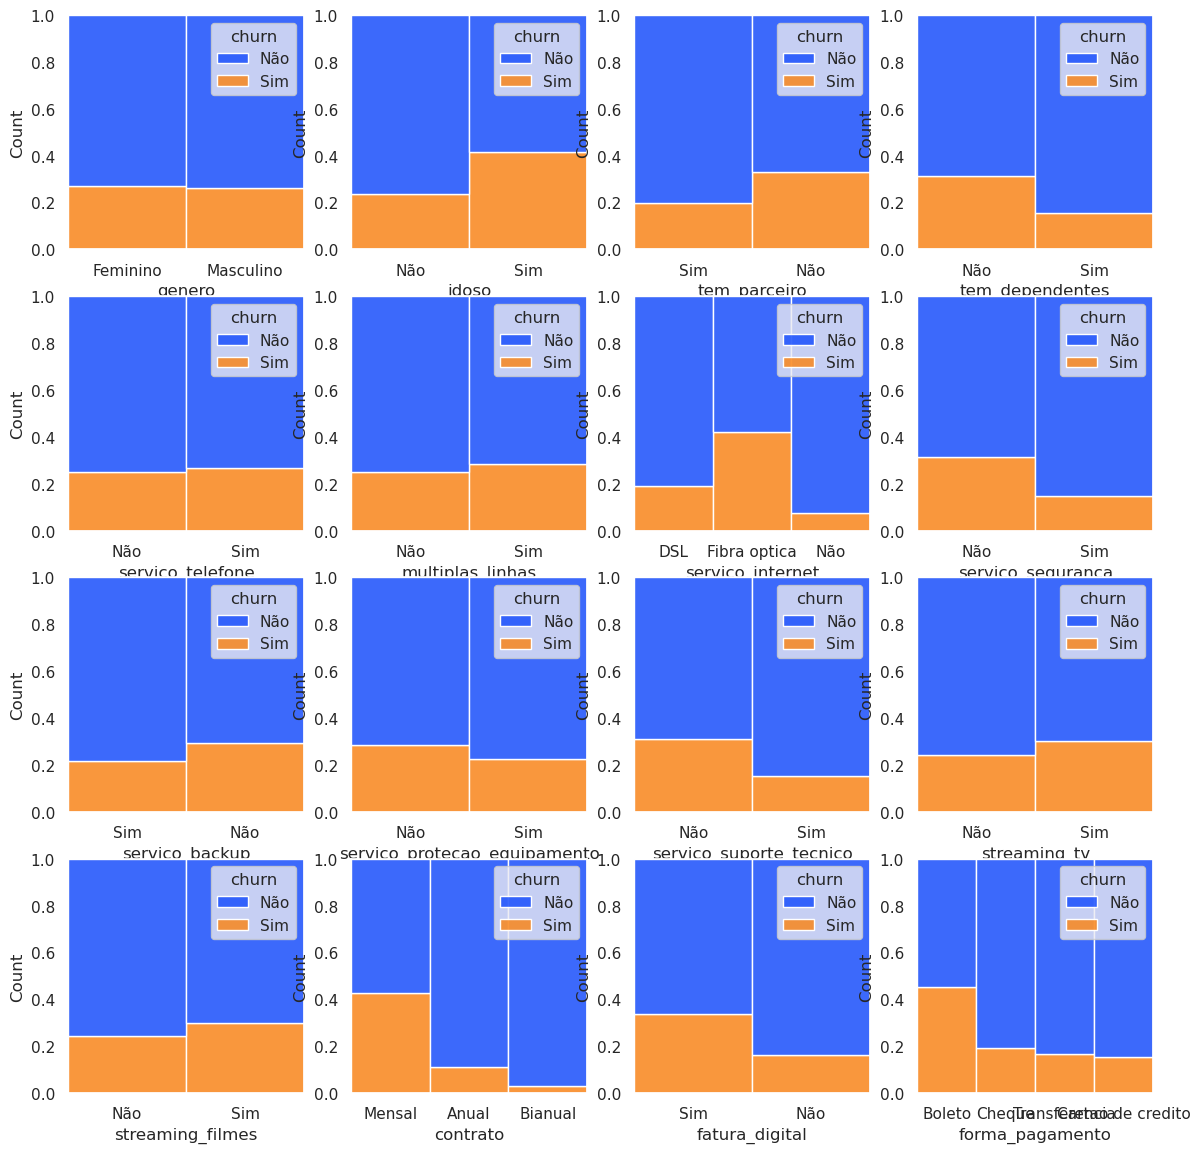

In [7]:
fig, axs = plt.subplots(ncols=4, nrows=4, figsize=(14, 14))

for i, coluna in enumerate(colunas_categoricas):
    sns.histplot(x=coluna, data=df_churn, hue="churn", multiple="fill", ax=axs.flat[i])

plt.show()

In [8]:
print(axs)

[[<Axes: xlabel='genero', ylabel='Count'>
  <Axes: xlabel='idoso', ylabel='Count'>
  <Axes: xlabel='tem_parceiro', ylabel='Count'>
  <Axes: xlabel='tem_dependentes', ylabel='Count'>]
 [<Axes: xlabel='servico_telefone', ylabel='Count'>
  <Axes: xlabel='multiplas_linhas', ylabel='Count'>
  <Axes: xlabel='servico_internet', ylabel='Count'>
  <Axes: xlabel='servico_seguranca', ylabel='Count'>]
 [<Axes: xlabel='servico_backup', ylabel='Count'>
  <Axes: xlabel='servico_protecao_equipamento', ylabel='Count'>
  <Axes: xlabel='servico_suporte_tecnico', ylabel='Count'>
  <Axes: xlabel='streaming_tv', ylabel='Count'>]
 [<Axes: xlabel='streaming_filmes', ylabel='Count'>
  <Axes: xlabel='contrato', ylabel='Count'>
  <Axes: xlabel='fatura_digital', ylabel='Count'>
  <Axes: xlabel='forma_pagamento', ylabel='Count'>]]


In [9]:
print(list(axs.flat))

[<Axes: xlabel='genero', ylabel='Count'>, <Axes: xlabel='idoso', ylabel='Count'>, <Axes: xlabel='tem_parceiro', ylabel='Count'>, <Axes: xlabel='tem_dependentes', ylabel='Count'>, <Axes: xlabel='servico_telefone', ylabel='Count'>, <Axes: xlabel='multiplas_linhas', ylabel='Count'>, <Axes: xlabel='servico_internet', ylabel='Count'>, <Axes: xlabel='servico_seguranca', ylabel='Count'>, <Axes: xlabel='servico_backup', ylabel='Count'>, <Axes: xlabel='servico_protecao_equipamento', ylabel='Count'>, <Axes: xlabel='servico_suporte_tecnico', ylabel='Count'>, <Axes: xlabel='streaming_tv', ylabel='Count'>, <Axes: xlabel='streaming_filmes', ylabel='Count'>, <Axes: xlabel='contrato', ylabel='Count'>, <Axes: xlabel='fatura_digital', ylabel='Count'>, <Axes: xlabel='forma_pagamento', ylabel='Count'>]


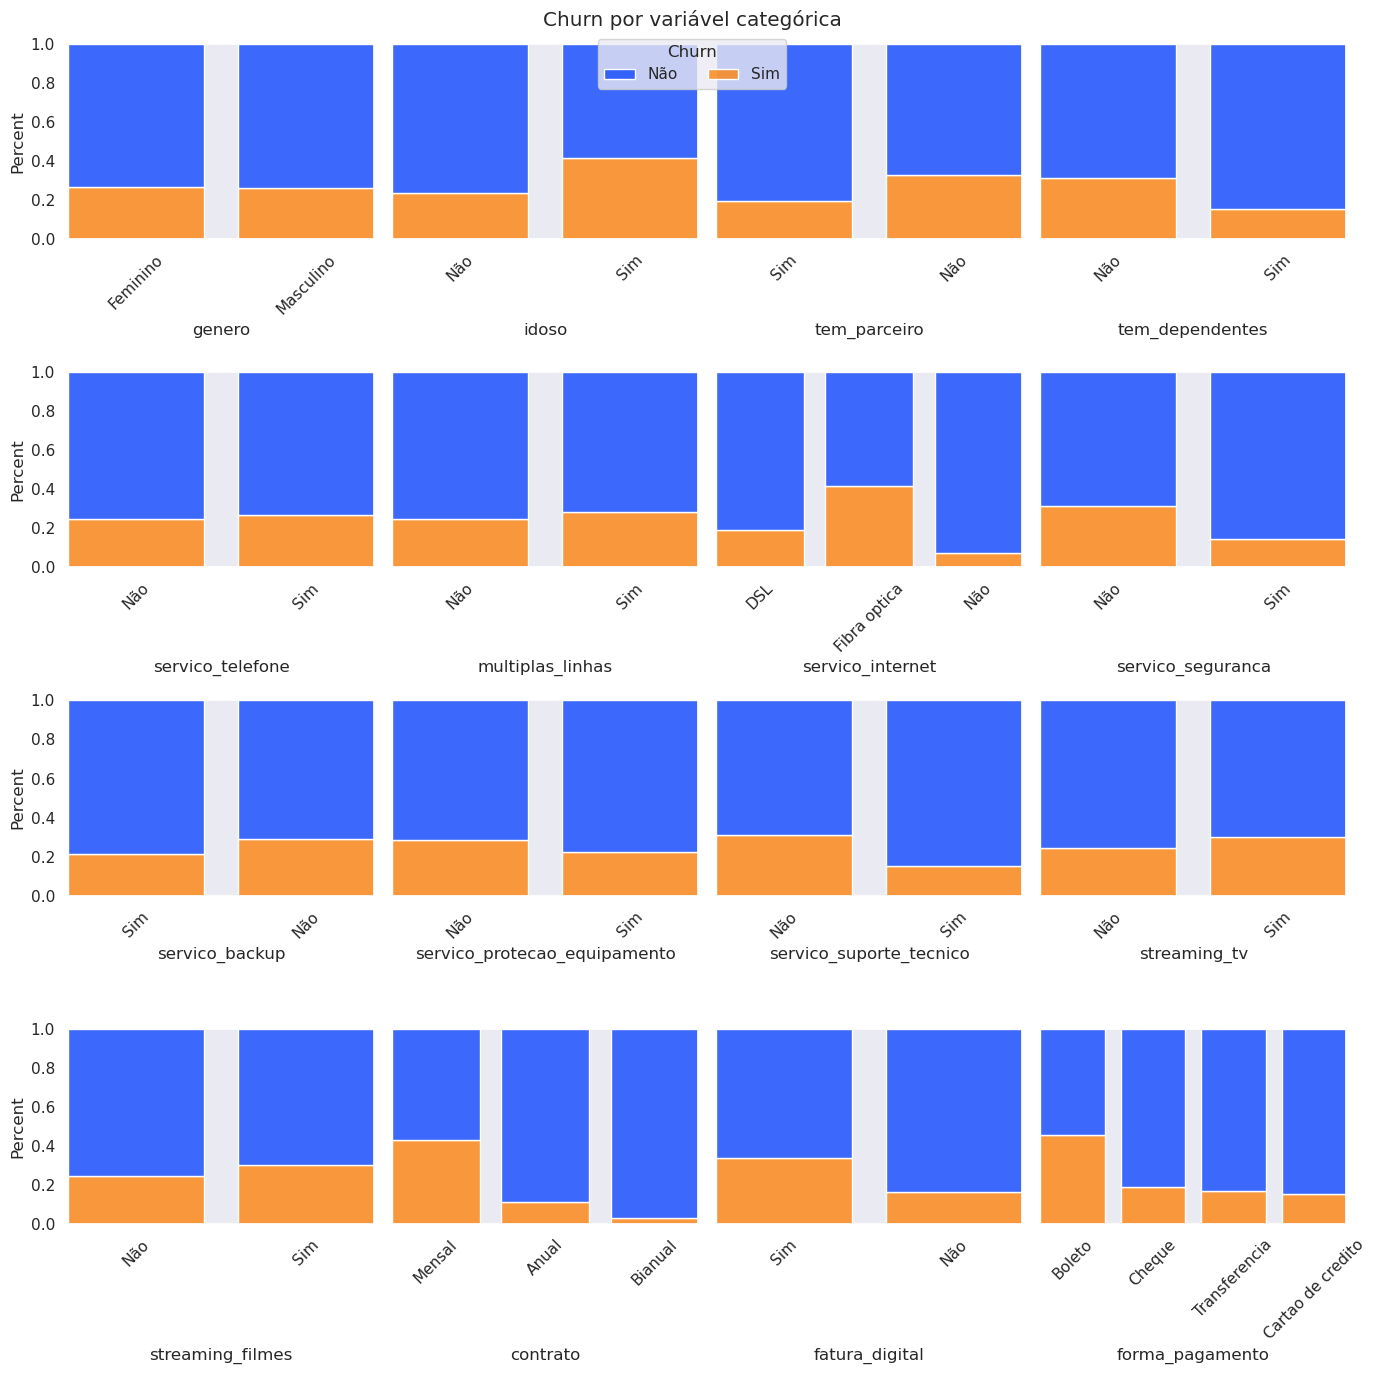

In [10]:
fig, axs = plt.subplots(ncols=4, nrows=4, figsize=(14, 14), sharey=True,  tight_layout=True)

for i, coluna in enumerate(colunas_categoricas):
   h = sns.histplot(x=coluna, data=df_churn, hue="churn", multiple="fill", ax=axs.flat[i], stat="percent", shrink=0.8)
   h.tick_params(axis="x", labelrotation=45)
   legenda = h.get_legend()
   legenda.remove()

rotulos = [text.get_text() for text in legenda.get_texts()]

fig.legend(handles=legenda.legend_handles, labels=rotulos, loc="upper center", ncols=2, title="Churn", bbox_to_anchor=(0.5, 0.965))
fig.suptitle("Churn por variável categórica")
   

fig.align_labels()


plt.show()

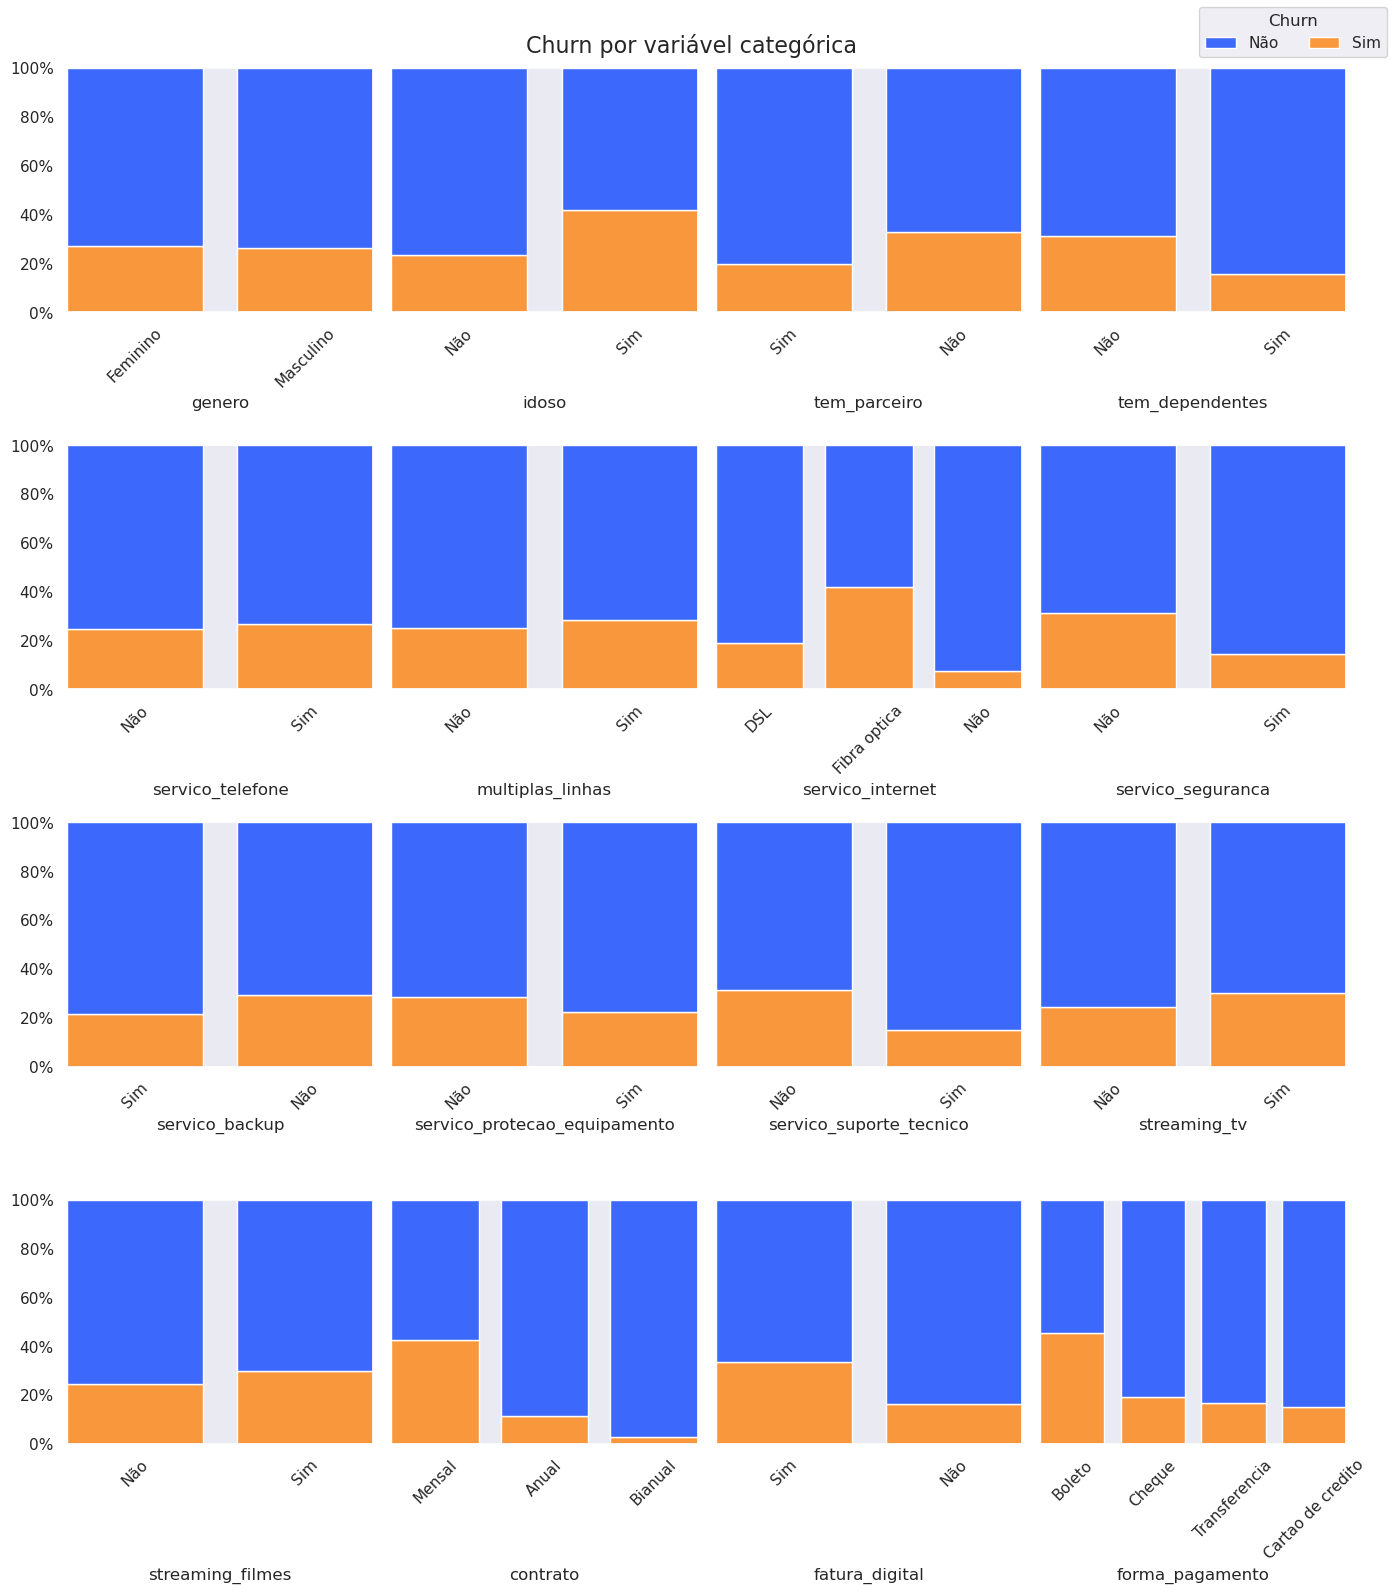

In [27]:
from matplotlib.ticker import PercentFormatter

fig, axs = plt.subplots(ncols=4, nrows=4, figsize=(14, 16), sharey=True,  tight_layout=True)

for i, coluna in enumerate(colunas_categoricas):
   h = sns.histplot(x=coluna, data=df_churn, hue="churn", multiple="fill", ax=axs.flat[i], stat="percent", 
                    shrink=0.8, common_norm=True)
   h.tick_params(axis="x", labelrotation=45)
   h.grid(False)

   legend = h.get_legend()
   legend.remove()

   h.yaxis.set_major_formatter(PercentFormatter(1))
   h.set_ylabel("")


labels = [text.get_text() for text in legend.get_texts()]

fig.legend(handles=legend.legend_handles, labels=labels, loc="upper right", ncols=10, title="Churn")
fig.suptitle("Churn por variável categórica", fontsize=16)


fig.align_labels()


plt.show()

In [15]:
print(h.containers)

[<BarContainer object of 4 artists>, <BarContainer object of 4 artists>]


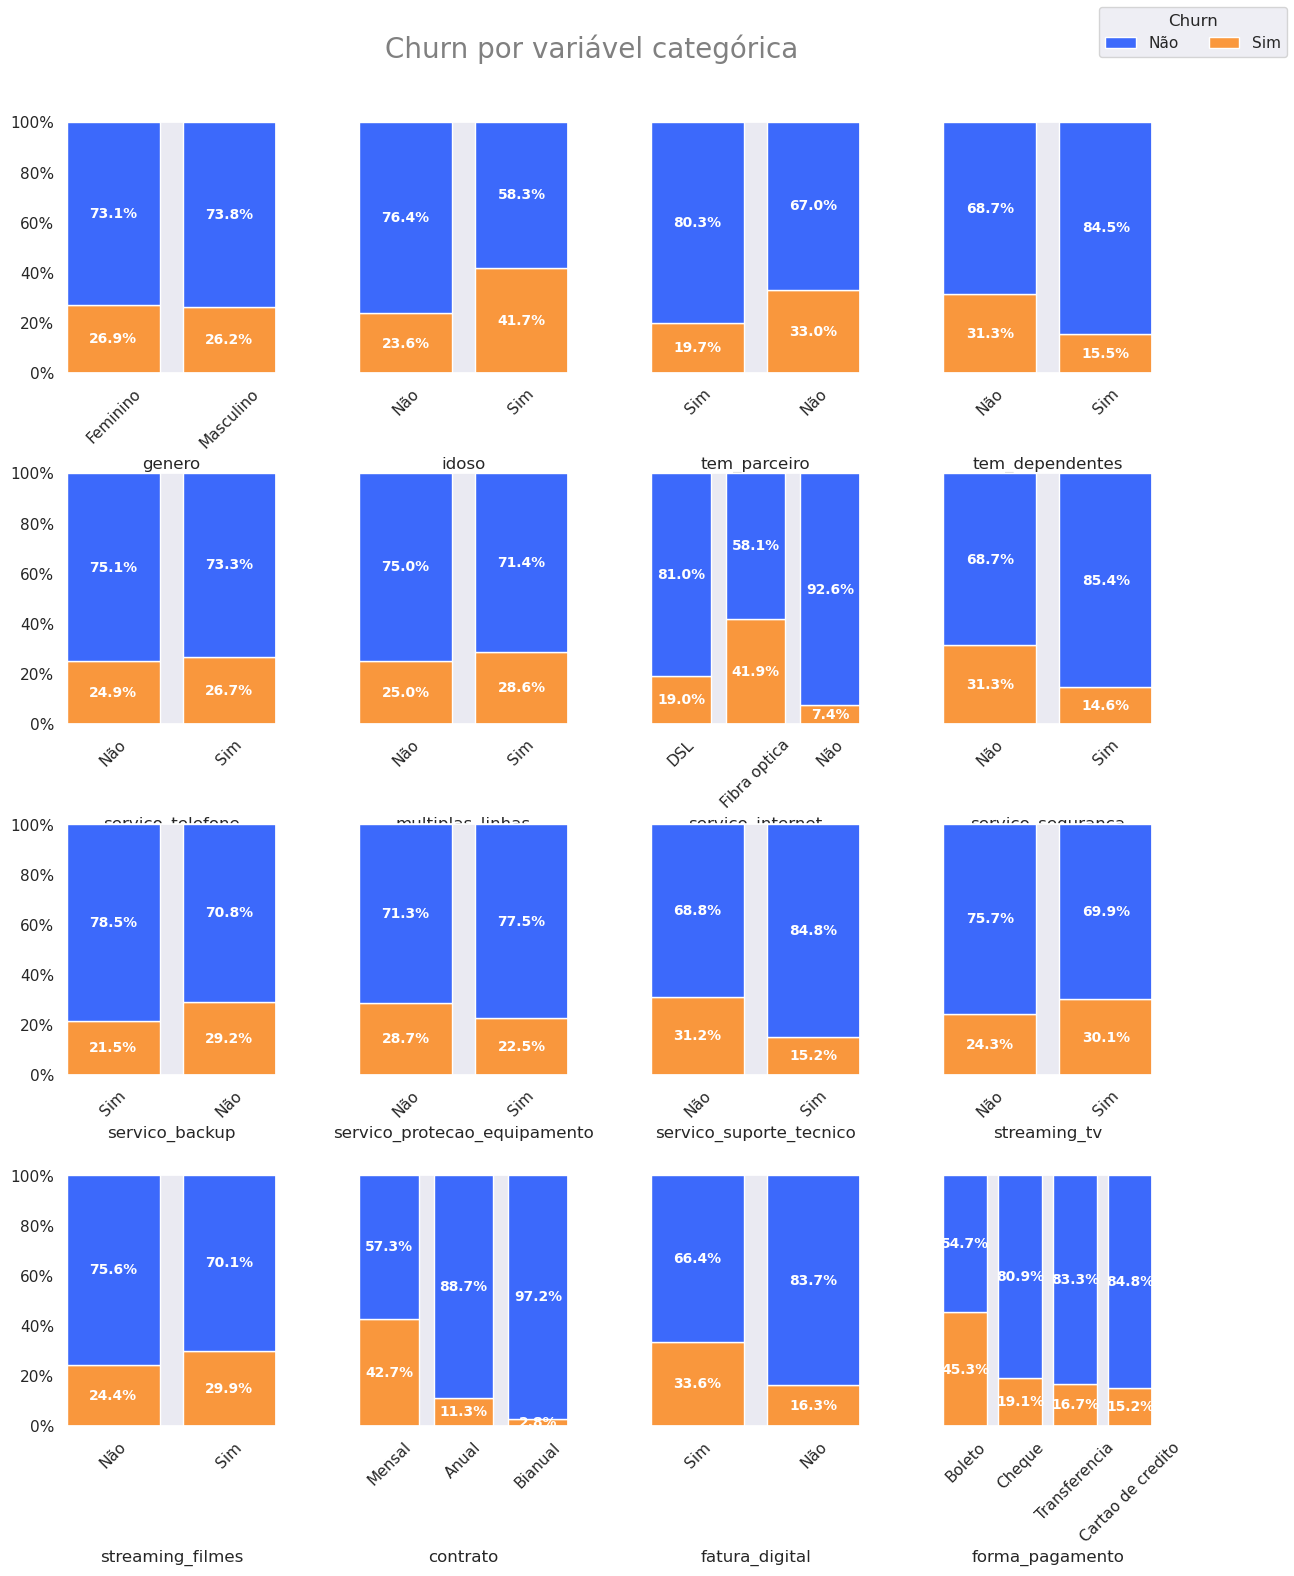

In [35]:
from matplotlib.ticker import PercentFormatter

fig, axs = plt.subplots(ncols=4, nrows=4, figsize=(14, 16), sharey=True)

for i, coluna in enumerate(colunas_categoricas):
   h = sns.histplot(x=coluna, data=df_churn, hue="churn", multiple="fill", ax=axs.flat[i], stat="percent", 
                    shrink=0.8, common_norm=True)
   h.tick_params(axis="x", labelrotation=45)
   h.grid(False)

   legend = h.get_legend()
   legend.remove()

   h.yaxis.set_major_formatter(PercentFormatter(1))
   h.set_ylabel("")

   for barra in h.containers:
        h.bar_label(barra, label_type="center", labels=[f"{parte.get_height():.1%}" for parte in barra], color="white", weight="bold", fontsize=10) 


labels = [text.get_text() for text in legend.get_texts()]

fig.legend(handles=legend.legend_handles, labels=labels, loc="upper right", ncols=10, title="Churn")
fig.suptitle("Churn por variável categórica", fontsize=20, color="gray")


fig.align_labels()

plt.subplots_adjust(wspace=0.4, hspace=0.4, top=0.925)


plt.show()

Recursos que parecem estar positivamente correlacionados com a rotatividade:

- contratos mensais
- ausência de backup online, segurança online e serviços de proteção de dispositivos
- ausência de suporte técnico
- ser um idoso
- fatura digital
- pagar com boleto
- serviço de internet por fibra óptica

Recursos que parecem estar negativamente correlacionados com a rotatividade:

- contratos de dois anos
- ausência de serviço de internet
- ter um parceiro ou dependente

Vamos quantificar essas correlações em breve. Primeiro, vamos tentar interpretar os resultados.

Ambos os sexos se comportam de maneira semelhante quando se trata de migrar para outro provedor de serviços.

Talvez o serviço de internet fornecido pela empresa tenha problemas de conectividade, particularmente o de fibra óptica. Também pode ser que a configuração não seja fácil, de modo que aqueles que optaram por não ter suporte técnico possam não conseguir usar os serviços. E isso seria mais grave em clientes idosos. Embora pareça que existam problemas com a internet de fibra óptica, a DSL tem uma taxa de rotatividade muito menor, apesar de ser uma conexão mais lenta.

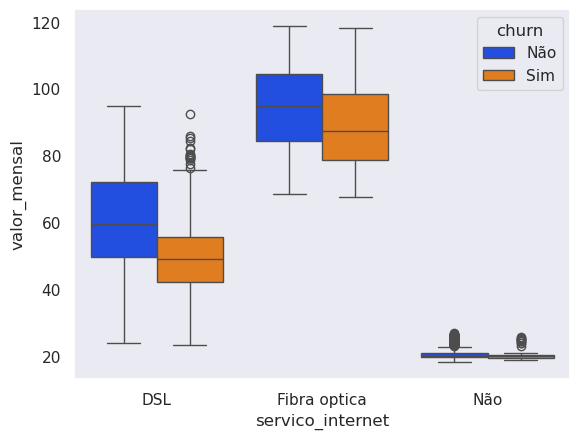

In [36]:
sns.boxplot(x='servico_internet', y='valor_mensal', hue='churn', data=df_churn); 